For using Colab GPU, preprocessed data are saved at Google Drive at Folder ML_project

In [10]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/ML_project/' # For MGA

import numpy as np

# Adjust 'ML_Project' if you named your Drive folder something else!
file_path = drive_path + 'processed_train_data.npz'

# Load the preprocessed data
data = np.load(file_path)
x_train_full = data['x'] 
y_train_full = data['y'] 

# Normalize pixel values
x_train_full = x_train_full.astype('float32') / 255.0

print(f"Loaded training data shape: {x_train_full.shape}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded training data shape: (9227, 51, 45, 1)


In [11]:
y_train = y_train_full
X_train = x_train_full

test_data_path = drive_path + 'processed_test_data.npz' 
test_data = np.load(test_data_path)
x_test = test_data['x'].astype('float32') / 255.0
test_ids = test_data['ids'].astype(int) - 1 # Adjust IDs to be correctly indexed 



In [12]:
import numpy as np

# 1. Labels for the Binary Classifier (0 vs. 1+)
# 0 stays 0. Anything > 0 becomes 1.
y_train_binary = (y_train > 0).astype(int)


# 2. Data and Labels for the Counting Classifier (1, 2, 3 persons)
# Filter out all '0 person' data from the training set
occupied_indices = np.where(y_train > 0)[0]
X_train_counting = X_train[occupied_indices]

# Shift the labels so they are 0, 1, 2 (for 1, 2, 3 persons respectively)
# Neural networks expect labels to start at 0.
y_train_counting = y_train[occupied_indices] - 1 



In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_binary_cnn(input_shape=(51, 45, 1)):
    model = models.Sequential()

    # --- Block 1 ---
    # padding='same' ensures the output feature map is the same spatial size as the input
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25)) # Drop 25% of connections to prevent overfitting

    # --- Block 2 ---
    # Increasing filters as spatial dimensions reduce
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # # --- Block 3 ---
    model.add(layers.Conv2D(128, kernel_size=(5, 5), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    # model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.1))

    # --- Fully Connected (Dense) Classifier ---
    model.add(layers.Flatten())
    
    # Dense hidden layer to combine the extracted features
    model.add(layers.Dense(1024))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('gelu'))
    model.add(layers.Dropout(0.25))

    # Dense hidden layer
    model.add(layers.Dense(64))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5)) # Higher dropout before the final output

    # --- Output Layer ---
    # 4 units for your 4 classes (0, 1, 2, 3 persons)
    # Softmax turns the outputs into probabilities (summing to 1.0)
    model.add(layers.Dense(1, activation='sigmoid'))
    return model


binary_model = build_binary_cnn()
binary_model.compile(optimizer=optimizers.Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# add early stopping to prevent overfitting
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(X_train, y_train_binary, test_size=0.1)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
binary_model.fit(x_train, y_train, batch_size=32, epochs=1000, validation_data=(x_val, y_val), callbacks=[early_stopping])

Epoch 1/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9438 - loss: 0.1847 - val_accuracy: 0.5970 - val_loss: 0.6307
Epoch 2/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9876 - loss: 0.0541 - val_accuracy: 0.9621 - val_loss: 0.2350
Epoch 3/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9912 - loss: 0.0340 - val_accuracy: 0.9935 - val_loss: 0.0260
Epoch 4/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9945 - loss: 0.0213 - val_accuracy: 0.9892 - val_loss: 0.0233
Epoch 5/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9976 - loss: 0.0121 - val_accuracy: 0.9935 - val_loss: 0.0315
Epoch 6/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9974 - loss: 0.0112 - val_accuracy: 0.9989 - val_loss: 0.0034
Epoch 7/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9959 - loss: 0.0170 - val_accuracy: 0.9967 - val_loss: 0.0080
Epoch 8/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9980 - loss: 0.

In [16]:
def build_counting_cnn(input_shape=(51, 45, 1)):
    model = models.Sequential()
     # --- Block 1 ---
    # padding='same' ensures the output feature map is the same spatial size as the input
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25)) # Drop 25% of connections to prevent overfitting

    # --- Block 2 ---
    # Increasing filters as spatial dimensions reduce
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # # --- Block 3 ---
    model.add(layers.Conv2D(128, kernel_size=(5, 5), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    # model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.1))

    # --- Fully Connected (Dense) Classifier ---
    model.add(layers.Flatten())
    
    # Dense hidden layer to combine the extracted features
    model.add(layers.Dense(1024))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('gelu'))
    model.add(layers.Dropout(0.25))

    # Dense hidden layer
    model.add(layers.Dense(64))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5)) # Higher dropout before the final output

    # --- Output Layer ---
    # 4 units for your 4 classes (0, 1, 2, 3 persons)
    # Softmax turns the outputs into probabilities (summing to 1.0)
    model.add(layers.Dense(3, activation='sigmoid'))
    return model

counting_model = build_counting_cnn()
counting_model.compile(optimizer=optimizers.Adam(learning_rate=0.0005),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
x_train, x_val, y_train, y_val = train_test_split(X_train_counting, y_train_counting, test_size=0.1)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
counting_model.fit(x_train, y_train, batch_size=32, epochs=1000, validation_data=(x_val, y_val), callbacks=[early_stopping])

Epoch 1/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.6511 - loss: 0.8533 - val_accuracy: 0.4080 - val_loss: 1.3654
Epoch 2/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7730 - loss: 0.5491 - val_accuracy: 0.5830 - val_loss: 0.9679
Epoch 3/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8031 - loss: 0.4689 - val_accuracy: 0.7259 - val_loss: 0.7304
Epoch 4/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8394 - loss: 0.4027 - val_accuracy: 0.8829 - val_loss: 0.3188
Epoch 5/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8562 - loss: 0.3624 - val_accuracy: 0.8636 - val_loss: 0.3355
Epoch 6/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8705 - loss: 0.3266 - val_accuracy: 0.8816 - val_loss: 0.3097
Epoch 7/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8808 - loss: 0.3053 - val_accuracy: 0.8147 - val_loss: 0.5210
Epoch 8/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8917 - loss: 

In [23]:
from google.colab import files
import os
import numpy as np
import pandas as pd

# Load the test data in Colab
test_data_path = drive_path + 'processed_test_data.npz' 
test_data = np.load(test_data_path)
x_test = test_data['x'].astype('float32') / 255.0
test_ids = test_data['ids']

# check if first id equals 9227
if test_ids[0] == 9227:
    print("✅ Test IDs are correctly indexed starting at 9227.")
else:
    test_ids = test_ids.astype(int) - 1 # Adjust IDs to be correctly indexed
    print("First id is:", test_ids[0])

# ==========================================
# --- STAGE 1 & 2 PIPELINE PREDICTIONS ---
# ==========================================

print("Running Stage 1: Binary Classification (0 vs 1+)...")
# 1. Ask the binary model: Is someone there?
presence_prob = binary_model.predict(x_test)
is_occupied_mask = (presence_prob > 0.5).flatten() # Creates a True/False mask

# Initialize an array of zeros for our final predictions
# Everyone defaults to '0 persons' initially
predicted_classes = np.zeros(len(x_test), dtype=int)

# 2. Extract ONLY the radar frames where the binary model detected people
occupied_x_test = x_test[is_occupied_mask]

# 3. Ask the counting model: How many? 
if len(occupied_x_test) > 0:
    print(f"Running Stage 2: Counting Classification on {len(occupied_x_test)} frames...")
    count_probs = counting_model.predict(occupied_x_test)
    
    # argmax gets 0, 1, or 2. We add 1 to map back to 1, 2, or 3 persons.
    predicted_counts = np.argmax(count_probs, axis=1) + 1
    
    # 4. Inject the counting predictions back into the original array
    # using the True/False mask we created in Stage 1
    predicted_classes[is_occupied_mask] = predicted_counts

# ==========================================
# --- KAGGLE SUBMISSION SAVING ---
# ==========================================

# Note: Because you have two models, a single validation history doesn't exist anymore.
# To keep your file-saving logic intact, manually input your evaluated combined accuracy here,
# or extract the individual max accuracies (e.g., binary_val_acc * counting_val_acc).
binary_val_acc = binary_model.history.history['val_accuracy'][-1] # <--- REPLACE with your actual binary model validation accuracy
counting_val_acc = counting_model.history.history['val_accuracy'][-1] # <--- REPLACE with your actual counting model
combined_val_acc = binary_val_acc * counting_val_acc # <--- REPLACE with your actual combined accuracy
print(f"✅ Pipeline predictions complete. Assumed accuracy for filename: {combined_val_acc:.4f}")

# Create the Kaggle submission dataframe
submission_df = pd.DataFrame({
    'id': test_ids,
    'target': predicted_classes
})

# Save to CSV for Kaggle to Google Drive
# Number the submission file with index to avoid overwriting previous submissions
existing_files = [f for f in os.listdir(drive_path) if f.startswith('my_kaggle_submission')]
submission_index = len(existing_files) + 1

# Format validation accuracy for filename
v_acc_str = f"{combined_val_acc*100:.2f}".replace('.', '-') 
file_path = f'{drive_path}my_kaggle_submission_{str(submission_index).zfill(3)}_Vacc_{v_acc_str}.csv'

submission_df.to_csv(file_path, index=False)
print(f"✅ Submission successfully saved to your Google Drive at: {file_path}")


First id is: 9227
Running Stage 1: Binary Classification (0 vs 1+)...
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Running Stage 2: Counting Classification on 3359 frames...
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
✅ Pipeline predictions complete. Assumed accuracy for filename: 0.9060
✅ Submission successfully saved to your Google Drive at: /content/drive/MyDrive/ML_project/my_kaggle_submission_008_Vacc_90-60.csv


289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


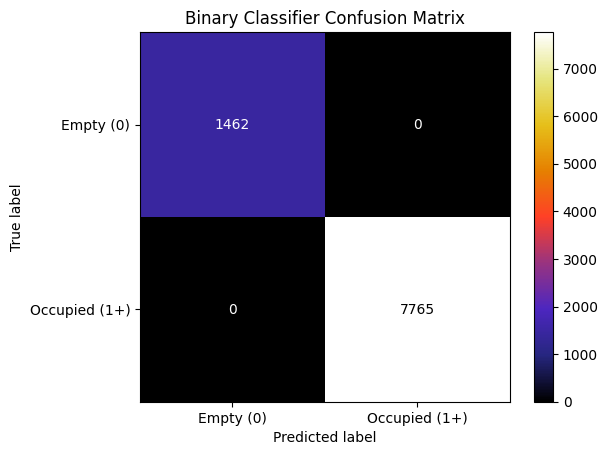

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Get predictions from the binary model
# Since binary_model uses sigmoid, it returns probabilities (0.0 to 1.0)
binary_preds_probs = binary_model.predict(x_train_full)
binary_preds = (binary_preds_probs > 0.5).astype(int)

# 2. Generate the confusion matrix
y_train_binary = (y_train_full > 0).astype(int) # Ensure labels are in binary format
binary_mtx = confusion_matrix(y_train_binary, binary_preds)

# 3. Display the matrix
# Labels should match your 0 vs 1+ logic
disp = ConfusionMatrixDisplay(
    confusion_matrix=binary_mtx, 
    display_labels=['Empty (0)', 'Occupied (1+)']
)

disp.plot(cmap=plt.cm.CMRmap)
plt.title('Binary Classifier Confusion Matrix')
plt.show()

289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


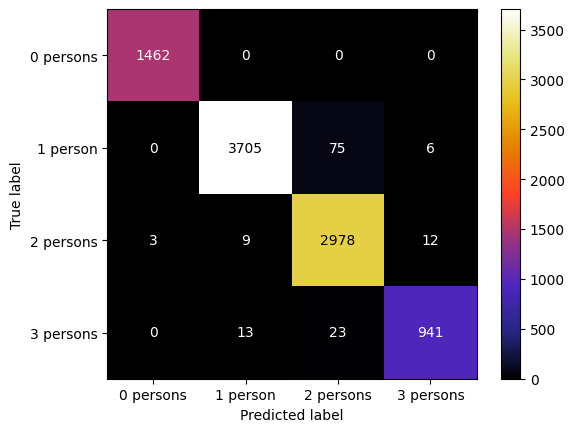

In [8]:
confusion_mtx = confusion_matrix(y_train_full, model.predict(x_train_full).argmax(axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mtx, display_labels=['0 persons', '1 person', '2 persons', '3 persons'])
disp.plot(cmap=plt.cm.CMRmap)

In [9]:
# print f1 score
from sklearn.metrics import f1_score
y_val_pred = model.predict(x_val).argmax(axis=1)
f1 = f1_score(y_val, y_val_pred, average='weighted')
print(f"✅ Model validation F1 score: {f1:.4f}")


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
✅ Model validation F1 score: 0.9400
